# Overfitting and Early Stopping

This notebook starts directly from a train/validation split for a nonlinear ring-classification problem. The goal is to compare the model selected by early stopping with the model obtained after training to the maximum number of iterations.


In [1]:
import random

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# Reproducibility
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

torch.set_default_dtype(torch.float32)

plt.rcParams.update({
    "figure.figsize": (7.2, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


def make_ring_data(n=840, noise=0.08):
    """A simple nonlinear two-class dataset in dimensionless coordinates."""
    X = 2.6 * torch.rand(n, 2) - 1.3
    r = torch.sqrt((X ** 2).sum(dim=1))
    y = ((r > 0.55) & (r < 1.05)).float()
    X = X + noise * torch.randn_like(X)
    return X, y


X_ring, y_ring = make_ring_data()
Nneurons = 16

print("PyTorch version:", torch.__version__)
print(f"Ring dataset: {len(X_ring)} points")


PyTorch version: 2.2.2
Ring dataset: 840 points


Training points: 672, validation points: 168
Max iterations: 3500
Best validation BCE: 0.277 at step 267
Early-stopping accuracy: train 0.911, validation 0.881
Max-iteration accuracy: train 0.915, validation 0.893


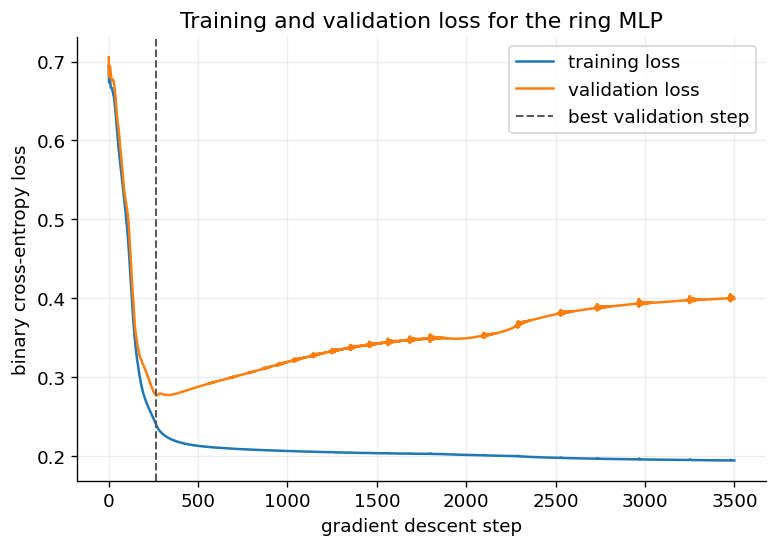

/var/folders/xs/7436fth96c550p00b17kx1q40000gn/T/ipykernel_43388/1161898908.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


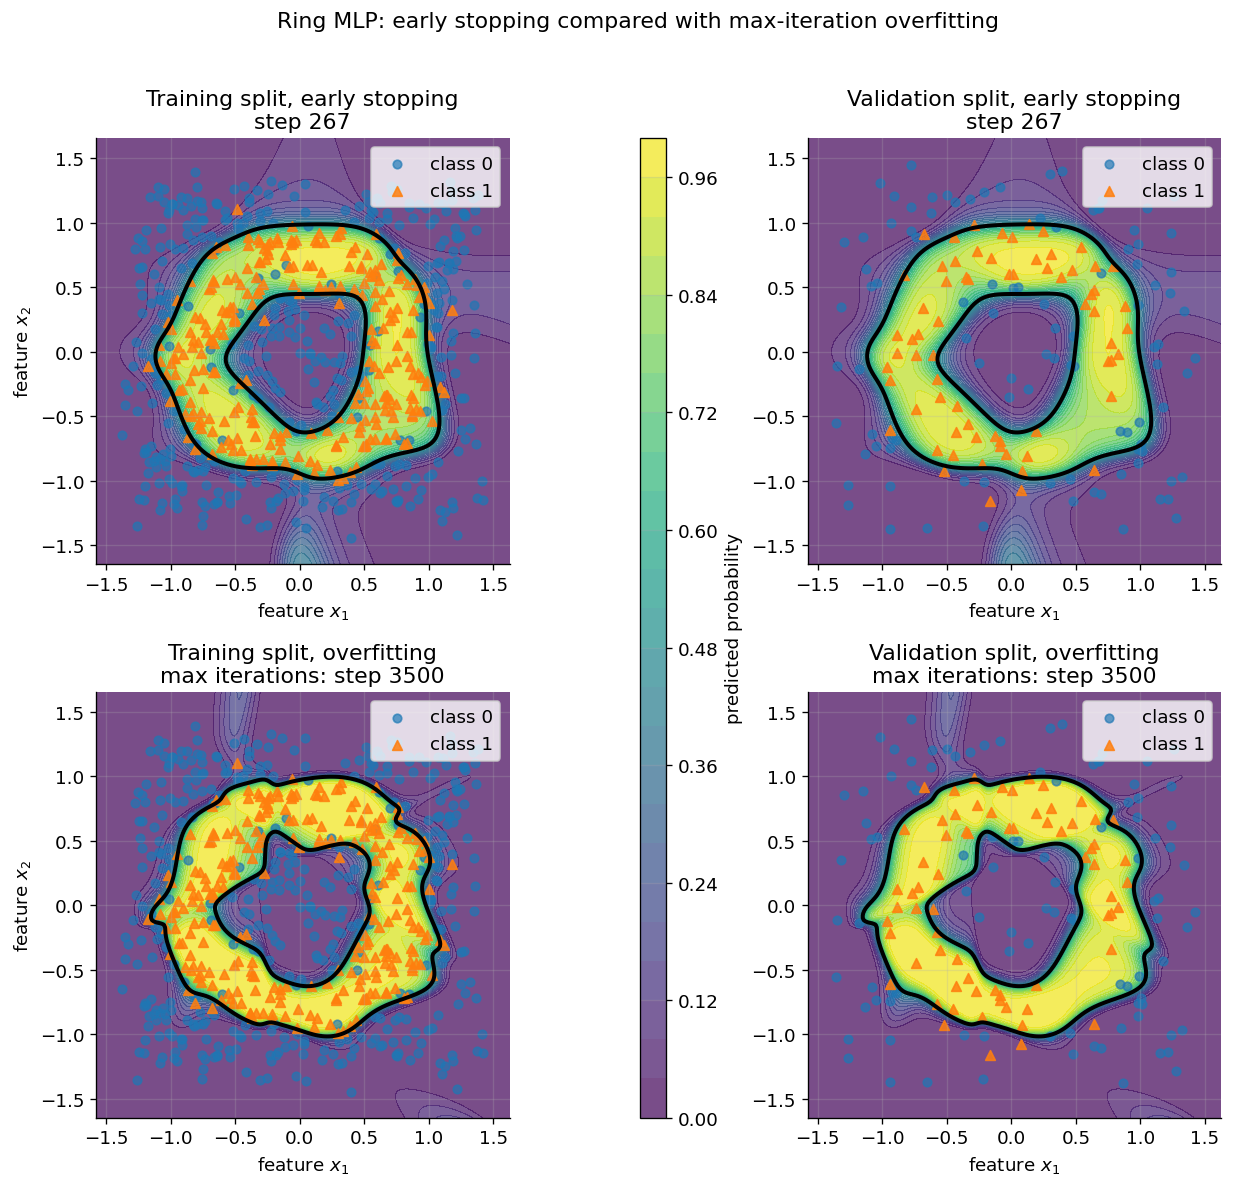

<All keys matched successfully>

In [2]:
# Train the ring MLP again with a separate validation set.
validation_fraction = 0.20
max_validation_steps = 3500
use_early_stopping = True
early_stopping_min_delta = 1e-4

validation_seed = 42
split_generator = torch.Generator().manual_seed(validation_seed)
indices = torch.randperm(len(X_ring), generator=split_generator)
n_validation = int(validation_fraction * len(indices))
validation_indices = indices[:n_validation]
train_indices = indices[n_validation:]

X_ring_train, y_ring_train = X_ring[train_indices], y_ring[train_indices]
X_ring_validation, y_ring_validation = X_ring[validation_indices], y_ring[validation_indices]

torch.manual_seed(validation_seed)
mlp_ring_validation = nn.Sequential(
    nn.Linear(2, Nneurons),
    nn.Tanh(),
    nn.Linear(Nneurons, 1),
)

validation_optimizer = torch.optim.AdamW(mlp_ring_validation.parameters(), lr=0.03)
validation_loss_fn = nn.BCEWithLogitsLoss()
train_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_validation_step = 0
best_validation_state = None

for step in range(1, max_validation_steps + 1):
    mlp_ring_validation.train()
    train_logits = mlp_ring_validation(X_ring_train).squeeze(-1)
    train_loss = validation_loss_fn(train_logits, y_ring_train)
    validation_optimizer.zero_grad()
    train_loss.backward()
    validation_optimizer.step()

    mlp_ring_validation.eval()
    with torch.no_grad():
        step_train_loss = validation_loss_fn(
            mlp_ring_validation(X_ring_train).squeeze(-1),
            y_ring_train,
        ).item()
        step_validation_loss = validation_loss_fn(
            mlp_ring_validation(X_ring_validation).squeeze(-1),
            y_ring_validation,
        ).item()

    train_losses.append(step_train_loss)
    validation_losses.append(step_validation_loss)

    if step_validation_loss < best_validation_loss - early_stopping_min_delta:
        best_validation_loss = step_validation_loss
        best_validation_step = step
        best_validation_state = {
            name: value.detach().clone()
            for name, value in mlp_ring_validation.state_dict().items()
        }

max_iteration_state = {
    name: value.detach().clone()
    for name, value in mlp_ring_validation.state_dict().items()
}

if use_early_stopping and best_validation_state is not None:
    early_stopping_state = best_validation_state
    early_stopping_step = best_validation_step
else:
    early_stopping_state = max_iteration_state
    early_stopping_step = max_validation_steps


def accuracy_for_state(state, X_split, y_split):
    mlp_ring_validation.load_state_dict(state)
    with torch.no_grad():
        predictions = (torch.sigmoid(mlp_ring_validation(X_split).squeeze(-1)) > 0.5).float()
    return (predictions == y_split).float().mean().item()


early_train_accuracy = accuracy_for_state(early_stopping_state, X_ring_train, y_ring_train)
early_validation_accuracy = accuracy_for_state(early_stopping_state, X_ring_validation, y_ring_validation)
max_train_accuracy = accuracy_for_state(max_iteration_state, X_ring_train, y_ring_train)
max_validation_accuracy = accuracy_for_state(max_iteration_state, X_ring_validation, y_ring_validation)

print(f"Training points: {len(train_indices)}, validation points: {len(validation_indices)}")
print(f"Max iterations: {max_validation_steps}")
print(f"Best validation BCE: {best_validation_loss:.3f} at step {best_validation_step}")
print(
    f"Early-stopping accuracy: train {early_train_accuracy:.3f}, "
    f"validation {early_validation_accuracy:.3f}"
)
print(
    f"Max-iteration accuracy: train {max_train_accuracy:.3f}, "
    f"validation {max_validation_accuracy:.3f}"
)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
steps_run = np.arange(1, len(train_losses) + 1)
ax.plot(steps_run, train_losses, label="training loss")
ax.plot(steps_run, validation_losses, label="validation loss")
ax.axvline(best_validation_step, color="0.35", linestyle="--", linewidth=1.2, label="best validation step")
ax.set_xlabel("gradient descent step")
ax.set_ylabel("binary cross-entropy loss")
ax.set_title("Training and validation loss for the ring MLP")
ax.grid(alpha=0.22)
ax.legend()
plt.show()

x1_min = X_ring[:, 0].min().item() - 0.2
x1_max = X_ring[:, 0].max().item() + 0.2
x2_min = X_ring[:, 1].min().item() - 0.2
x2_max = X_ring[:, 1].max().item() + 0.2
x1_validation_grid = torch.linspace(x1_min, x1_max, 180)
x2_validation_grid = torch.linspace(x2_min, x2_max, 180)
XX_validation, YY_validation = torch.meshgrid(
    x1_validation_grid,
    x2_validation_grid,
    indexing="xy",
)
ring_validation_grid = torch.stack(
    [XX_validation.reshape(-1), YY_validation.reshape(-1)],
    dim=1,
)


def probability_grid_for_state(state):
    mlp_ring_validation.load_state_dict(state)
    with torch.no_grad():
        return torch.sigmoid(
            mlp_ring_validation(ring_validation_grid).squeeze(-1)
        ).reshape(XX_validation.shape)


early_probability_grid = probability_grid_for_state(early_stopping_state)
max_probability_grid = probability_grid_for_state(max_iteration_state)


def plot_validation_split_panel(ax, probability_grid, X_split, y_split, title, show_ylabel=True):
    im = ax.contourf(
        XX_validation.numpy(),
        YY_validation.numpy(),
        probability_grid.numpy(),
        levels=25,
        alpha=0.72,
    )
    ax.contour(
        XX_validation.numpy(),
        YY_validation.numpy(),
        probability_grid.numpy(),
        levels=[0.5],
        colors="black",
        linewidths=2.4,
    )
    y_split_np = y_split.numpy().astype(int)
    ax.scatter(
        X_split[y_split_np == 0, 0],
        X_split[y_split_np == 0, 1],
        s=26,
        alpha=0.68,
        label="class 0",
    )
    ax.scatter(
        X_split[y_split_np == 1, 0],
        X_split[y_split_np == 1, 1],
        s=34,
        marker="^",
        alpha=0.84,
        label="class 1",
    )
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_xlabel("feature $x_1$")
    if show_ylabel:
        ax.set_ylabel("feature $x_2$")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=True, loc="upper right")
    return im

fig = plt.figure(figsize=(13.8, 10.6))
grid_spec = fig.add_gridspec(
    2,
    5,
    width_ratios=[1, 0.09, 0.045, 0.11, 1],
    hspace=0.30,
    wspace=0.0,
)
train_early_ax = fig.add_subplot(grid_spec[0, 0])
validation_early_ax = fig.add_subplot(grid_spec[0, 4], sharex=train_early_ax, sharey=train_early_ax)
train_max_ax = fig.add_subplot(grid_spec[1, 0], sharex=train_early_ax, sharey=train_early_ax)
validation_max_ax = fig.add_subplot(grid_spec[1, 4], sharex=train_early_ax, sharey=train_early_ax)
colorbar_ax = fig.add_subplot(grid_spec[:, 2])

im = plot_validation_split_panel(
    train_early_ax,
    early_probability_grid,
    X_ring_train,
    y_ring_train,
    f"Training split, early stopping\nstep {early_stopping_step}",
)
plot_validation_split_panel(
    validation_early_ax,
    early_probability_grid,
    X_ring_validation,
    y_ring_validation,
    f"Validation split, early stopping\nstep {early_stopping_step}",
    show_ylabel=False,
)
plot_validation_split_panel(
    train_max_ax,
    max_probability_grid,
    X_ring_train,
    y_ring_train,
    f"Training split, overfitting\nmax iterations: step {max_validation_steps}",
)
plot_validation_split_panel(
    validation_max_ax,
    max_probability_grid,
    X_ring_validation,
    y_ring_validation,
    f"Validation split, overfitting\nmax iterations: step {max_validation_steps}",
    show_ylabel=False,
)

cbar = fig.colorbar(im, cax=colorbar_ax)
cbar.set_label("predicted probability")
fig.suptitle("Ring MLP: early stopping compared with max-iteration overfitting")
plt.tight_layout()
plt.show()

mlp_ring_validation.load_state_dict(early_stopping_state)


# Summary

The training loss measures how well the model fits the points used for optimization. The validation loss measures how well the same model works on held-out points.

When the training loss keeps decreasing but the validation loss stops improving, the model is beginning to specialize too much to the training split. That is the overfitting signal.

Early stopping keeps the parameter state from the best validation step. The max-iteration model shows what happens if we continue optimizing after that point.


# Exercises

1. Increase `max_validation_steps`. Does the max-iteration boundary become more complicated?

2. Change `Nneurons` in the setup cell. How does model capacity affect the gap between training and validation loss?

3. Increase the noise in `make_ring_data`. Does early stopping happen earlier or later?

4. Set `use_early_stopping = False`. Which state is used as the early-stopping comparison?

5. Try `Adam` instead of `AdamW`. Does the overfitting pattern change?
